<a href="https://colab.research.google.com/github/jaemeee109/Ai25Study/blob/MASTER/(EXAM)%20%EB%AA%A8%EB%8D%B8_%EC%BC%80%EB%9D%BC%EC%8A%A4_%ED%8C%8C%EC%9D%BC%2C_MBC_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

In [ ]:
# 더미데이터 전처리

#  MNIST 데이터
fashion_mnist = keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

print("원본 훈련 데이터 shape:", x_train_full.shape)
print("원본 훈련 레이블 shape:", y_train_full.shape)
print("원본 테스트 데이터 shape:", x_test.shape)
print("원본 테스트 레이블 shape:", y_test.shape)

class_names = ["티셔츠", "바지", "스웨터", "드레스", "코트",
               "샌달", "셔츠", "스니커즈", "가방", "앵클부츠"]

#  더미 데이터 전처리
dummy_x = x_train_full[:5]
dummy_y = y_train_full[:5]

print("\n[더미 데이터 전처리 결과]")
print("dummy_x shape:", dummy_x.shape)
print("dummy_y:", dummy_y)
print("dummy_x[0] 최소값 / 최대값:", dummy_x[0].min(), dummy_x[0].max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
원본 훈련 데이터 shape: (60000, 28, 28)
원본 훈련 레이블 shape: (60000,)
원본 테스트 데이터 shape: (10000, 28, 28)
원본 테스트 레이블 shape: (10000,)

[더미 데이터 전처리 결과]
dummy_x shape: (5, 28, 28)
dummy_y: [9 0 0 3 0]
dummy_x[0] 최소값 / 최대값: 0 255


In [ ]:
# 훈련/검증/테스트 데이터 전처리 및 shape

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_full = np.expand_dims(x_train_full, -1)  # (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, -1)              # (10000, 28, 28, 1)

print("전처리 후 전체 훈련 데이터 shape:", x_train_full.shape)
print("전처리 후 테스트 데이터 shape:", x_test.shape)

x_val = x_train_full[:10000]
y_val = y_train_full[:10000]

x_train = x_train_full[10000:]
y_train = y_train_full[10000:]

print("\n[데이터셋 shape]")
print("x_train:", x_train.shape, " y_train:", y_train.shape)
print("x_val:", x_val.shape, " y_val:", y_val.shape)
print("x_test:", x_test.shape, " y_test:", y_test.shape)


전처리 후 전체 훈련 데이터 shape: (60000, 28, 28, 1)
전처리 후 테스트 데이터 shape: (10000, 28, 28, 1)

[데이터셋 shape]
x_train: (50000, 28, 28, 1)  y_train: (50000,)
x_val: (10000, 28, 28, 1)  y_val: (10000,)
x_test: (10000, 28, 28, 1)  y_test: (10000,)


In [ ]:
# 모델용 객체 메서드 생성

def create_fashion_cnn_model(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        #  과대적합 방지
        layers.Dropout(0.25),

        layers.Flatten(),

        # 과대적합 방지
        layers.Dense(128, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.5),


        layers.Dense(num_classes, activation="softmax")
    ])
    return model

# 모델 객체 생성
model = create_fashion_cnn_model()
print(model)  # 객체(모델) 정보 출력


<Sequential name=sequential, built=True>


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 다중 분류를 이용한 컴파일



optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# 과대적합 방지
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

print("모델 컴파일 완료")


모델 컴파일 완료


In [6]:
# 모델 훈련

EPOCHS = 20
BATCH_SIZE = 128

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.6404 - loss: 1.0195 - val_accuracy: 0.8356 - val_loss: 0.4628 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.8250 - loss: 0.5078 - val_accuracy: 0.8632 - val_loss: 0.4004 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.8483 - loss: 0.4516 - val_accuracy: 0.8806 - val_loss: 0.3608 - learning_rate: 0.0010
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.8637 - loss: 0.4089 - val_accuracy: 0.8786 - val_loss: 0.3510 - learning_rate: 0.0010
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.8668 - loss: 0.3913 - val_accuracy: 0.8915 - val_loss: 0.3289 - learning_rate: 0.0010
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.8811 - loss: 0.3646 - val_accuracy: 0.8942 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.8821 

In [8]:
# 모델 요약

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

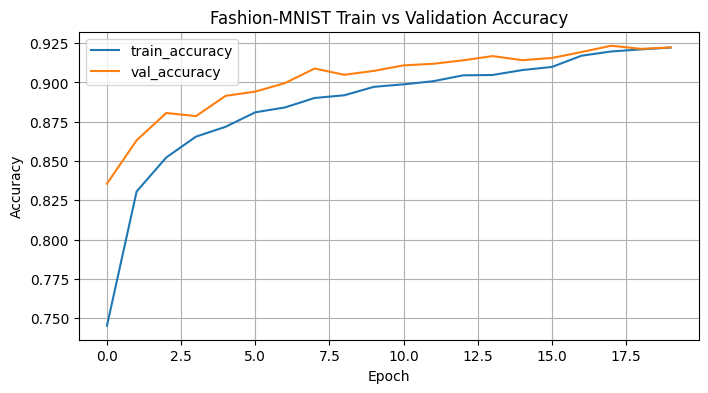

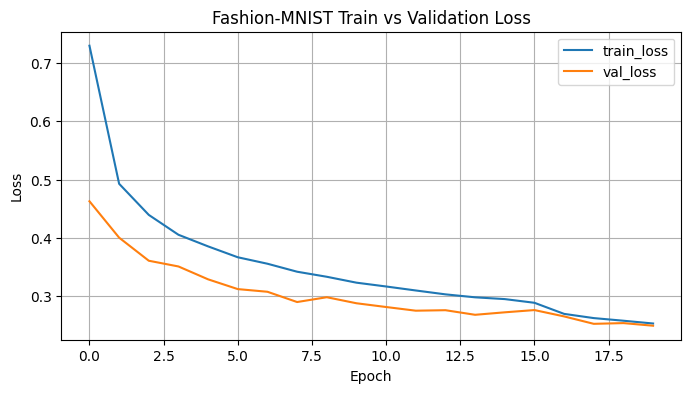

In [9]:
#  훈련 결과 그래프

# 정확도 그래프
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Fashion-MNIST Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 손실 그래프
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Fashion-MNIST Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# 모델 저장 (.keras)

model.save("fashion_cnn_model.keras")
print("모델 저장 완료")


모델 저장 완료


In [12]:
# 모델을 불러와 테스트 점수를 확인

loaded_model = keras.models.load_model("fashion_cnn_model.keras")

val_loss, val_acc = loaded_model.evaluate(x_val, y_val, verbose=0)
print("검증 세트 손실(Val Loss):", round(val_loss, 4))
print("검증 세트 정확도(Val Accuracy):", round(val_acc, 4))


검증 세트 손실(Val Loss): 0.2494
검증 세트 정확도(Val Accuracy): 0.9223


In [13]:
# 모델을 불러와 테스트 세트 점수 출력

test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print("테스트 세트 손실(Test Loss):", round(test_loss, 4))
print("테스트 세트 정확도(Test Accuracy):", round(test_acc, 4))

테스트 세트 손실(Test Loss): 0.2751
테스트 세트 정확도(Test Accuracy): 0.915
